## Task 1: Data Profile – Air Quality Dataset

The dataset is inspected using:
- shape() to determine dimensions
- columns to identify available features
- info() to examine data types
- describe() for summary statistics
- isnull().sum() to detect missing values
- duplicated().sum() to detect duplicate records

These checks help determine data quality before analysis.


In [19]:
import pandas as pd

aqi = pd.read_csv("/content/sample_data/city_day.csv")
crop = pd.read_csv("/content/sample_data/crop_production.csv")

print("===== AIR QUALITY DATASET =====")
print("Shape:", aqi.shape)
print("\nColumns:")
print(aqi.columns)

print("\nInfo:")
print(aqi.info())

print("\nSummary Statistics:")
print(aqi.describe(include='all'))

print("\nMissing Values:")
print(aqi.isnull().sum())

print("\nDuplicate Records:")
print(aqi.duplicated().sum())


print("\n\n===== CROP YIELD DATASET =====")
print("Shape:", crop.shape)

print("\nColumns:")
print(crop.columns)

print("\nInfo:")
print(crop.info())

print("\nSummary Statistics:")
print(crop.describe(include='all'))

print("\nMissing Values:")
print(crop.isnull().sum())

print("\nDuplicate Records:")
print(crop.duplicated().sum())

===== AIR QUALITY DATASET =====
Shape: (29531, 16)

Columns:
Index(['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2',
       'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket'],
      dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float6


### Observations
Initial inspection revealed missing values, possible duplicate records, and inconsistent state names which may affect merging and model performance.

## Task 2: Missing Value Treatment Strategy

Numeric columns:
- AQI, PM2.5, PM10, NO2, CO, Area, Production
- Median imputation used because environmental and agricultural data often contain outliers.

Categorical columns:
- State, City, Crop, Season
- Mode imputation used because these are categorical variables.

Rows with excessive missing values (if any) were removed because they contain insufficient information.

Median is preferred over mean because it is less affected by extreme values.

In [21]:
print("Before Treatment")
print(aqi.isnull().sum())
print(crop.isnull().sum())

# AQI Dataset
for col in aqi.columns:

    if aqi[col].dtype == 'object':
        aqi[col].fillna(aqi[col].mode()[0], inplace=True)

    else:
        aqi[col].fillna(aqi[col].median(), inplace=True)


# Crop Dataset
for col in crop.columns:

    if crop[col].dtype == 'object':
        crop[col].fillna(crop[col].mode()[0], inplace=True)

    else:
        crop[col].fillna(crop[col].median(), inplace=True)


print("\nAfter Treatment")
print(aqi.isnull().sum())
print(crop.isnull().sum())

Before Treatment
City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64
State_Name          0
District_Name       0
Crop_Year           0
Season              0
Crop                0
Area                0
Production       3730
dtype: int64


/tmp/ipykernel_2230/1672748565.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  aqi[col].fillna(aqi[col].mode()[0], inplace=True)
/tmp/ipykernel_2230/1672748565.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr


After Treatment
City          0
Date          0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
Xylene        0
AQI           0
AQI_Bucket    0
dtype: int64
State_Name       0
District_Name    0
Crop_Year        0
Season           0
Crop             0
Area             0
Production       0
dtype: int64


## Task 3: State Name Cleaning

The crop dataset will later be used for aggregation and comparison. Therefore, state names must be standardized to avoid inconsistencies caused by extra spaces, different capitalisation, or alternative spellings.

The following steps were performed:

1. Removed leading and trailing spaces.
2. Converted state names to lowercase.
3. Corrected known spelling variations.
4. Removed duplicate records.

This ensures consistent grouping and analysis.


In [22]:
print("Unique States Before Cleaning")

print(crop['State_Name'].unique())

crop['State_Name'] = (
    crop['State_Name']
    .str.strip()
    .str.lower()
)

state_mapping = {

    'orissa':'odisha',
    'uttaranchal':'uttarakhand',
    'pondicherry':'puducherry'

}

crop['State_Name'] = crop['State_Name'].replace(state_mapping)

#removing duplicates
print("Records Before:", len(crop))
crop = crop.drop_duplicates()
print("Records After:", len(crop))

#verifying
print(crop['State_Name'].unique())

Unique States Before Cleaning
['Andaman and Nicobar Islands' 'Andhra Pradesh' 'Arunachal Pradesh'
 'Assam' 'Bihar' 'Chandigarh' 'Chhattisgarh' 'Dadra and Nagar Haveli'
 'Goa' 'Gujarat' 'Haryana' 'Himachal Pradesh' 'Jammu and Kashmir '
 'Jharkhand' 'Karnataka' 'Kerala' 'Madhya Pradesh' 'Maharashtra' 'Manipur'
 'Meghalaya' 'Mizoram' 'Nagaland' 'Odisha' 'Puducherry' 'Punjab'
 'Rajasthan' 'Sikkim' 'Tamil Nadu' 'Telangana ' 'Tripura' 'Uttar Pradesh'
 'Uttarakhand' 'West Bengal']
Records Before: 246091
Records After: 246091
['andaman and nicobar islands' 'andhra pradesh' 'arunachal pradesh'
 'assam' 'bihar' 'chandigarh' 'chhattisgarh' 'dadra and nagar haveli'
 'goa' 'gujarat' 'haryana' 'himachal pradesh' 'jammu and kashmir'
 'jharkhand' 'karnataka' 'kerala' 'madhya pradesh' 'maharashtra' 'manipur'
 'meghalaya' 'mizoram' 'nagaland' 'odisha' 'puducherry' 'punjab'
 'rajasthan' 'sikkim' 'tamil nadu' 'telangana' 'tripura' 'uttar pradesh'
 'uttarakhand' 'west bengal']


### Inconsistencies Found

1. State names contained leading/trailing spaces.
2. State names used different letter cases.
3. State names were standardized to lowercase and stripped of extra spaces.
4. Duplicate records were checked and removed.

This ensures that state names are consistent before any merge operation.

## Task 4: Choice of Visualisation

A histogram was chosen to show how AQI values are distributed across observations.

A boxplot was chosen to identify extreme AQI values and determine whether a few highly polluted observations are affecting the average AQI.

Together these visualisations help understand both the concentration and spread of AQI values.



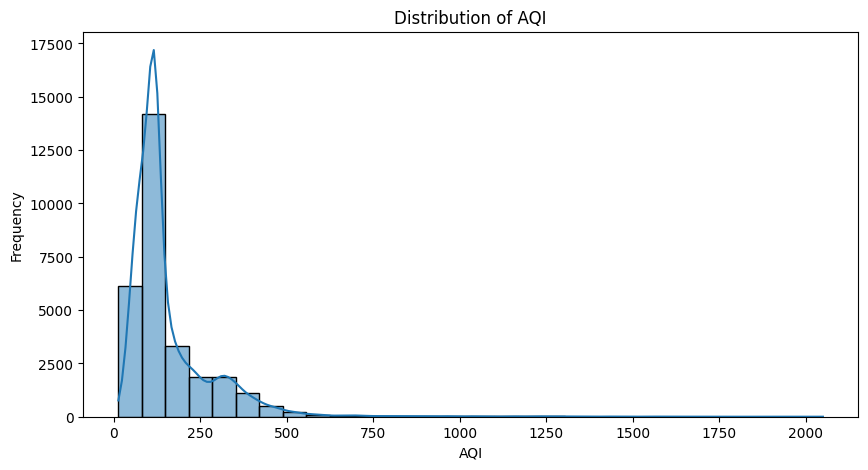

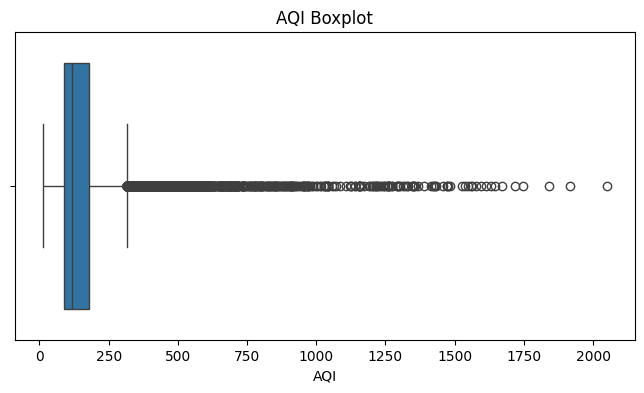

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

#histogram
plt.figure(figsize=(10,5))
sns.histplot(
    aqi['AQI'].dropna(),
    bins=30,
    kde=True
)
plt.title("Distribution of AQI")
plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.show()


#boxplot
plt.figure(figsize=(8,4))
sns.boxplot(
    x=aqi['AQI']
)
plt.title("AQI Boxplot")
plt.show()

### Observations

1. Most AQI values are grouped between lower and moderate ranges.

2. A few AQI readings are much higher than the rest, creating a long tail in the distribution.

3. The boxplot shows several outliers, which means some extreme pollution readings may affect the average AQI.

## Task 5: Outlier Detection Method

The Interquartile Range (IQR) method was selected because it is robust and does not assume a normal distribution.

Rather than deleting extreme values, capping was performed so that valuable information is retained while reducing the influence of unrealistic observations.

Number of Outliers: 3192


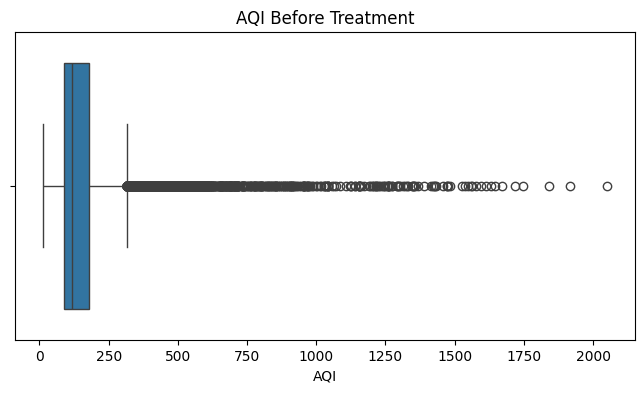

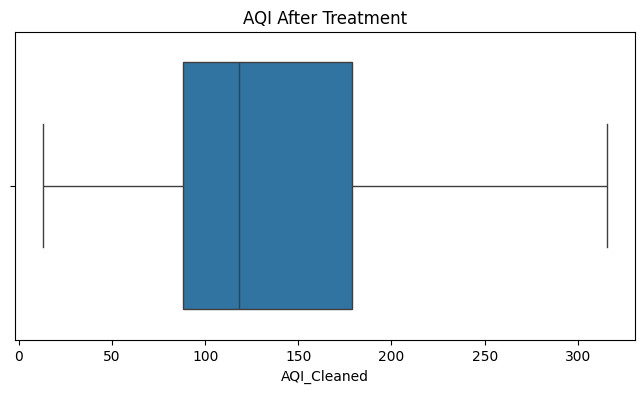

In [5]:
Q1 = aqi['AQI'].quantile(0.25)

Q3 = aqi['AQI'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)

upper_bound = Q3 + (1.5 * IQR)

outliers = aqi[
    (aqi['AQI'] < lower_bound) |
    (aqi['AQI'] > upper_bound)
]

print("Number of Outliers:", len(outliers))

#before treating outliers
plt.figure(figsize=(8,4))
sns.boxplot(x=aqi['AQI'])
plt.title("AQI Before Treatment")
plt.show()

#capping
aqi['AQI_Cleaned'] = aqi['AQI'].clip(
    lower=lower_bound,
    upper=upper_bound
)

#after treating
plt.figure(figsize=(8,4))
sns.boxplot(x=aqi['AQI_Cleaned'])
plt.title("AQI After Treatment")
plt.show()



### Observations

1. Before treatment, the AQI data contained many extreme outliers, as seen by the large number of points beyond the whiskers.

2. After treatment, the extreme values were capped, reducing the effect of unusually high AQI readings.

3. The cleaned data has a more balanced distribution and is better suited for further analysis and machine learning models.

## Task 6: Trend Analysis

The Date column was converted into datetime format and the year component was extracted.

Average AQI was then calculated for each year to identify long-term trends.

A line chart was selected because it clearly shows changes over time.

In [6]:
aqi['Date'] = pd.to_datetime(aqi['Date'])

aqi['Year'] = aqi['Date'].dt.year

yearly_aqi = (
    aqi.groupby('Year')['AQI']
    .mean()
    .reset_index()
)

yearly_aqi




,Year,AQI
0,2015,179.615137
1,2016,176.554629
2,2017,161.777138
3,2018,175.217277
4,2019,154.578297
5,2020,113.737624


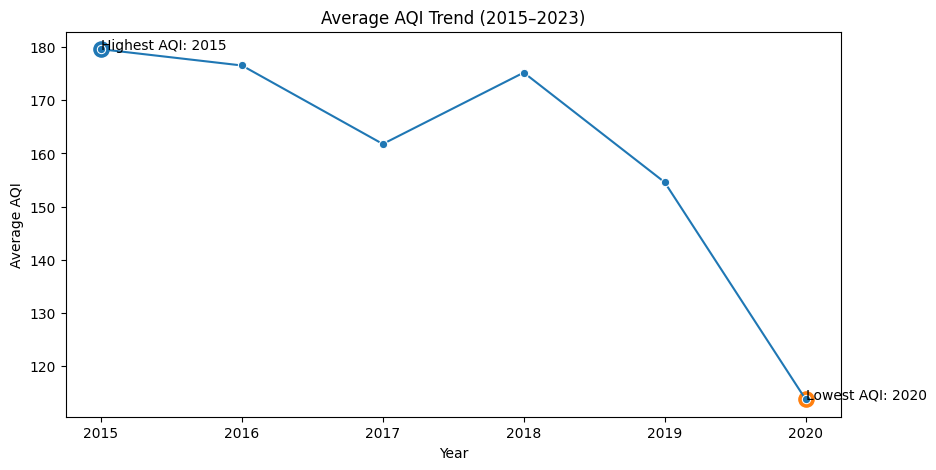

In [7]:
plt.figure(figsize=(10,5))
sns.lineplot(
    data=yearly_aqi,
    x='Year',
    y='AQI',
    marker='o'
)

max_year = yearly_aqi.loc[
    yearly_aqi['AQI'].idxmax()
]

min_year = yearly_aqi.loc[
    yearly_aqi['AQI'].idxmin()
]

plt.scatter(
    max_year['Year'],
    max_year['AQI'],
    s=120
)

plt.scatter(
    min_year['Year'],
    min_year['AQI'],
    s=120
)

plt.annotate(
    f"Highest AQI: {int(max_year['Year'])}",
    (max_year['Year'], max_year['AQI'])
)

plt.annotate(
    f"Lowest AQI: {int(min_year['Year'])}",
    (min_year['Year'], min_year['AQI'])
)

plt.title("Average AQI Trend (2015–2023)")
plt.xlabel("Year")
plt.ylabel("Average AQI")
plt.show()

### Interpretation

The graph shows that average AQI was highest in 2015 and lowest in 2020. Even though AQI increased slightly in some years, the overall trend moved downward over time. This suggests that air quality generally improved between 2015 and 2020. However, the data does not prove what caused this change.

## Task 7: Seasonal Air Quality Analysis

Monthly aggregation was chosen because it provides enough detail to reveal seasonal patterns while remaining easy to interpret.

The month was extracted from the Date column and average AQI was calculated for each month.

In [8]:
aqi['Month'] = aqi['Date'].dt.month

monthly_aqi = (
    aqi.groupby('Month')['AQI']
    .mean()
    .reset_index()
)

monthly_aqi

,Month,AQI
0,1,210.856925
1,2,189.808303
2,3,157.560931
3,4,139.535899
4,5,133.170861
5,6,119.833155
6,7,112.862022
7,8,114.417931
8,9,115.729406
9,10,176.943438


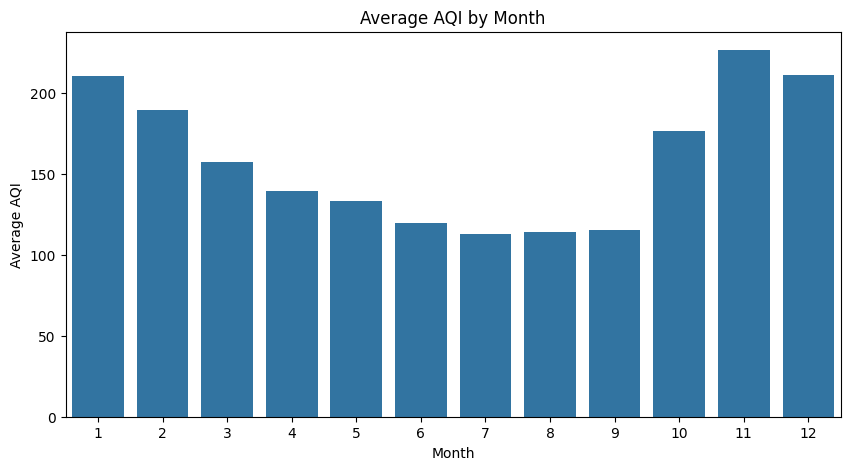

In [9]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=monthly_aqi,
    x='Month',
    y='AQI'
)

plt.title("Average AQI by Month")
plt.xlabel("Month")
plt.ylabel("Average AQI")
plt.show()

### Interpretation

AQI values are lower during the middle months of the year and rise sharply towards the end of the year. November and December have the highest average AQI levels. This supports the NGO's claim that pollution is generally worse during the October–December harvest season. However, other factors may also contribute to the increase in pollution.

## Task 8: Making the Datasets Compatible

The AQI dataset is recorded at city level while the crop dataset is recorded at state level.

A direct merge is not possible because the AQI dataset does not contain a State column.

To make the datasets compatible, city names would first need to be mapped to their corresponding states. After this transformation, AQI values could be aggregated to state-year level and merged with crop production data using State and Year.

This limitation was identified during preprocessing and highlights an important real-world data integration challenge.



To make them compatible:

1. A city-to-state mapping was created.
2. The Year was extracted from the AQI Date column.
3. AQI values were aggregated to state-year level.
4. The datasets were merged using State_Name and Year.

Without aggregation, one crop record would match many AQI records, creating duplicate and misleading results.

In [10]:
aqi['City'].unique()[:50]

array(['Ahmedabad', 'Aizawl', 'Amaravati', 'Amritsar', 'Bengaluru',
       'Bhopal', 'Brajrajnagar', 'Chandigarh', 'Chennai', 'Coimbatore',
       'Delhi', 'Ernakulam', 'Gurugram', 'Guwahati', 'Hyderabad',
       'Jaipur', 'Jorapokhar', 'Kochi', 'Kolkata', 'Lucknow', 'Mumbai',
       'Patna', 'Shillong', 'Talcher', 'Thiruvananthapuram',
       'Visakhapatnam'], dtype=object)

In [11]:
#city-state mapping

city_state = {

    'Ahmedabad':'gujarat',
    'Aizawl':'mizoram',
    'Amaravati':'andhra pradesh',
    'Amritsar':'punjab',
    'Bengaluru':'karnataka',
    'Bhopal':'madhya pradesh',
    'Brajrajnagar':'odisha',
    'Chandigarh':'chandigarh',
    'Chennai':'tamil nadu',
    'Coimbatore':'tamil nadu',
    'Delhi':'delhi',
    'Ernakulam':'kerala',
    'Gurugram':'haryana',
    'Guwahati':'assam',
    'Hyderabad':'telangana',
    'Jaipur':'rajasthan',
    'Jorapokhar':'jharkhand',
    'Kochi':'kerala',
    'Kolkata':'west bengal',
    'Lucknow':'uttar pradesh',
    'Mumbai':'maharashtra',
    'Patna':'bihar',
    'Shillong':'meghalaya',
    'Talcher':'odisha',
    'Thiruvananthapuram':'kerala',
    'Visakhapatnam':'andhra pradesh'
}

In [12]:
#creating state column
aqi['State_Name'] = (
    aqi['City']
    .map(city_state)
    .str.lower()
)

print(aqi[['City','State_Name']].head())

        City State_Name
0  Ahmedabad    gujarat
1  Ahmedabad    gujarat
2  Ahmedabad    gujarat
3  Ahmedabad    gujarat
4  Ahmedabad    gujarat


In [14]:
state_year_aqi = (
    aqi.groupby(['State_Name', 'Year'])['AQI']
       .mean()
       .reset_index()
)

state_year_aqi.head()

,State_Name,Year,AQI
0,andhra pradesh,2016,105.271739
1,andhra pradesh,2017,134.741935
2,andhra pradesh,2018,113.053425
3,andhra pradesh,2019,112.282192
4,andhra pradesh,2020,72.737705


In [15]:
print(state_year_aqi['Year'].min(), state_year_aqi['Year'].max())
print(crop['Crop_Year'].min(), crop['Crop_Year'].max())

2015 2020
1997 2014


In [16]:
aqi_2015 = state_year_aqi[
    state_year_aqi['Year'] == 2015
]

crop_2015 = crop[
    crop['Crop_Year'] == 2015
]

print(aqi_2015.shape)
print(crop_2015.shape)

print("AQI 2015 States:")
print(sorted(aqi_2015['State_Name'].unique()))


print("Crop 2015 States:")
print(sorted(crop_2015['State_Name'].unique()))



common_states = set(aqi_2015['State_Name']).intersection(
    set(crop_2015['State_Name'])
)

print(common_states)

(9, 3)
(0, 7)
AQI 2015 States:
['bihar', 'delhi', 'gujarat', 'haryana', 'karnataka', 'maharashtra', 'tamil nadu', 'telangana', 'uttar pradesh']
Crop 2015 States:
[]
set()


## Dataset Compatibility Assessment

Before merging the datasets, their structure and coverage were examined. The AQI dataset was available at the city-day level, while the crop dataset was available at the state-year level. To make them compatible, a city-to-state mapping was created and AQI values were aggregated to the state-year level.

Further investigation showed that the AQI dataset covered the years 2015–2020, whereas the crop dataset covered 1997–2015. Therefore, only the year 2015 was common between the two datasets.

After filtering both datasets to 2015 and comparing the available states, it was found that the AQI dataset contained data for Bihar, Delhi, Gujarat, Haryana, Karnataka, Maharashtra, Tamil Nadu, Telangana and Uttar Pradesh, while the crop dataset contained only Odisha and Sikkim. Because no common states were available after preprocessing, a meaningful merged dataset could not be created. Rather than forcing an invalid merge, this limitation was documented and reported.

This limitation was identified during exploratory analysis and demonstrates the importance of verifying data compatibility before attempting integration.


Since a meaningful merge could not be performed due to lack of overlapping states, relationships were explored within the crop dataset using a correlation matrix.

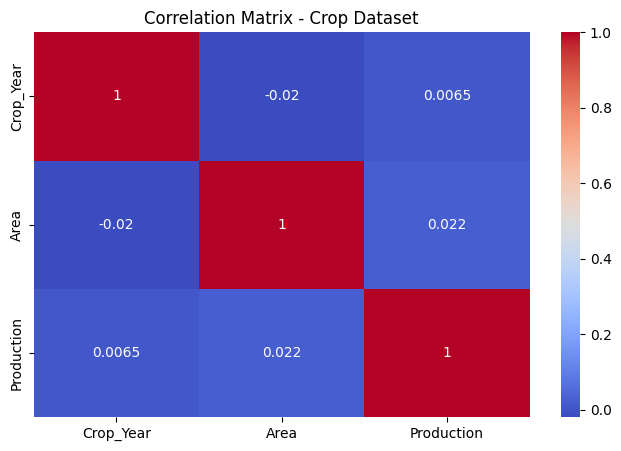

In [17]:
#correlation matrix only on crop dataset
numeric_crop = crop.select_dtypes(include='number')

plt.figure(figsize=(8,5))
sns.heatmap(
    numeric_crop.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix - Crop Dataset")
plt.show()

### Interpretation

The correlation values between the numerical features are very close to 0, indicating weak relationships between them. Area and Production show a slight positive correlation, suggesting that larger cultivated areas may lead to higher crop production. However, the relationship is very weak, and no strong patterns are visible in the dataset. Therefore, these variables do not appear to be strongly related based on the available data.

## Task 9: Briefing for the State Environment Minister

Madam Minister,

Based on the analysis, three important findings were observed.

First, air quality generally improved between 2015 and 2020, as the average AQI showed a downward trend over the years.

Second, pollution levels were not the same throughout the year. AQI values were highest during November and December, showing that pollution tends to increase towards the end of the year.

Third, an attempt was made to compare air quality with crop production. However, the two datasets did not have enough common states and years to be combined reliably, so a direct comparison could not be made.

These findings suggest that pollution control efforts should focus more on the months when pollution levels are highest. Monitoring and preventive measures during these periods may help reduce pollution exposure.

One limitation of this analysis is that the available data cannot prove whether pollution directly affects crop production. More complete data covering the same states and years would be needed to investigate that relationship.


## Optional Task C: One Plot to Rule Them All

### Selected Visualisation:
Average AQI Trend Across India (2015–2020)

### Caption

I chose this chart because it gives the clearest overall picture of how air quality changed over time. It shows that AQI was highest in 2015 and gradually decreased towards 2020, suggesting an overall improvement in air quality. Unlike other charts that focus on specific months or cities, this visual helps identify the long-term trend in pollution levels. However, the chart only shows the trend and cannot explain the exact reasons behind the changes, as factors such as weather, industrial activity, and government policies are not included in the dataset.

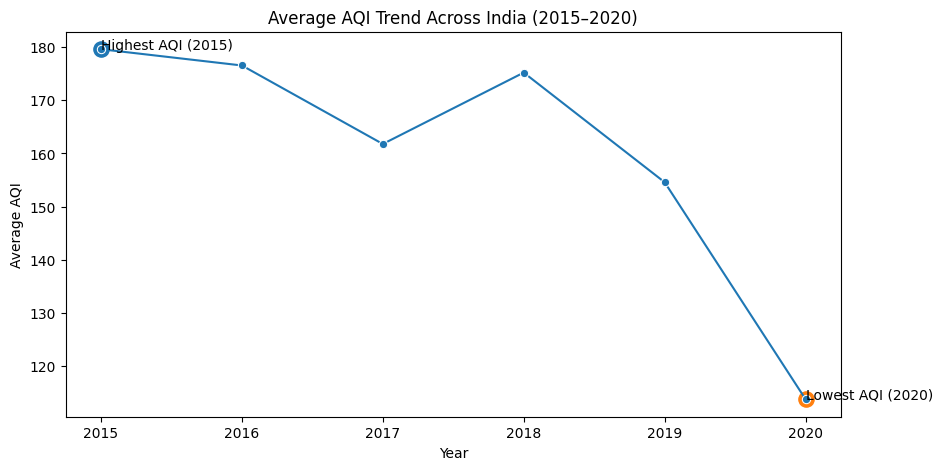

In [18]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=yearly_aqi,
    x='Year',
    y='AQI',
    marker='o'
)

max_year = yearly_aqi.loc[
    yearly_aqi['AQI'].idxmax()
]

min_year = yearly_aqi.loc[
    yearly_aqi['AQI'].idxmin()
]

plt.scatter(
    max_year['Year'],
    max_year['AQI'],
    s=120
)

plt.scatter(
    min_year['Year'],
    min_year['AQI'],
    s=120
)

plt.annotate(
    f"Highest AQI ({int(max_year['Year'])})",
    (max_year['Year'], max_year['AQI'])
)

plt.annotate(
    f"Lowest AQI ({int(min_year['Year'])})",
    (min_year['Year'], min_year['AQI'])
)

plt.title("Average AQI Trend Across India (2015–2020)")
plt.xlabel("Year")
plt.ylabel("Average AQI")

plt.show()